**Additional Work - Oscar**

**1 - Global function to estimate parameters for a superposition of two Thomas Process**

Goal : to create a global function  
- input : reals values of σ_1, ν_2, λ_p, μ 
- output : estimation of the parameters using the least squares on the estimated spectrum (estimated with the triangular taper method).


In [55]:
import sys
sys.path.append("../..")
from src.point_process import *
from src.utils import contrast, f4
import json
from sklearn.model_selection import ParameterGrid
import pandas as pd
import random


import matplotlib as mpl
print("LaTeX actif ?", mpl.rcParams['text.usetex'])

LaTeX actif ? False


In [56]:
with open('../../parameters/superposition-m-13.json', 'r') as file:
    params = json.load(file)
    
params['W']

[30, 30]

**Function with graphs**

In [57]:
def estimate_parameters_from_spectrum(sig1, nu2, lam_p, mu, W=params['W']):
    
    seed1 = random.randint(0, 10**6)
    seed2 = random.randint(0, 10**6)
    
    w, h = W
    nu1, sig2 = mu*sig1**2, np.sqrt(nu2/mu)
    theta_real = [mu, lam_p, sig1, nu2]


    # Génération des deux Thomas process
    thomas_process1 = ThomasProcess(lam_p, nu1, sig1)
    parents1, points_thomas1 = thomas_process1.generate(W, seed=seed1)
    thomas_process2 = ThomasProcess(lam_p, nu2, sig2)
    parents2, points_thomas2 = thomas_process2.generate(W, seed=seed2)
    points_sup = np.concatenate([points_thomas1, points_thomas2])

    # Affichage de la superposition
    display_superposition([points_thomas1, points_thomas2],
                           window=W,
                           title="Superposition of two Thomas processes",
                           labels=[
                               fr"$\lambda_p = {lam_p:.2f}$, $\nu = {nu1:.2f}$, $\sigma = {sig1:.2f}$",
                               fr"$\lambda_p = {lam_p:.2f}$, $\nu = {nu2:.2f}$, $\sigma = {sig2:.2f}$"
                           ])

    # Périodogramme par tapering triangulaire
    threshold = 0.2
    r_values = np.linspace(threshold, w/4, 1000)
    I_values = periodogram_tapering(points_sup, W, r_values, taper_triangle)

    # Estimation de l’intensité totale
    lam_hat = intensity(points_sup, W)

    # def des fonctions qui vont être utiles
    def f_theo_sup_2(theta, r):
        mu, lam_p, sig1, nu2 = theta
        return lam_p*(mu*sig1**2 + nu2) + (lam_hat/(mu*sig1**2 + nu2))*(mu**2*sig1**4*np.exp(-4*np.pi**2*sig1**2*r**2) + nu2**2*np.exp(-4*np.pi**2*nu2*r**2/mu))
    
    def contrast_aux_2(theta):
        g_theo = f_theo_sup_2(theta, r_values)
        dr = r_values[1] - r_values[0]
        return contrast(I_values, g_theo, dr)
    
    def rmse(y_true, y_pred):
        return np.sqrt(np.sum((y_true - y_pred)**2))
    
    def mape(y_true, y_pred):
        y_true = np.array(y_true)
        y_pred = np.array(y_pred)
        return np.abs((y_true - y_pred) / y_true) * 100


    # Choix des points initiaux pour l'algo d'optimisation
    mu_values = np.linspace(1, 200, 5)
    lamp_values = np.linspace(0.0005, 0.2, 5)
    sig1_values = np.linspace(0.05, 1.5, 5)
    nu2_values = np.linspace(0.05, 450, 5)

    param_grid = ParameterGrid({'mu': mu_values, 'lam_p': lamp_values, 'sig1': sig1_values, 'nu2': nu2_values})
    rmse_min, result_min, theta0_min = float('inf'), None, None

    for params in param_grid:
        theta0 = list(params.values())  # points initiaux
        bounds = [(1e-5, None)]*4 # intervalle de recherche 

        result = minimize(contrast_aux_2, theta0, method='L-BFGS-B', bounds=bounds)
        rmse_ = rmse(theta_real, result.x)
        if rmse_ < rmse_min:
            rmse_min, result_min, theta0_min = rmse_, result.x, theta0
    
    mu_hat, lamp_hat, sig1_hat, nu2_hat = result_min
    nu1_hat, sig2_hat = mu_hat*sig1_hat**2, np.sqrt(nu2_hat/mu_hat)
    theta_est = [mu_hat, lamp_hat, sig1_hat, nu2_hat]
    
    
    # Affichage : comparaison spectre réel vs estimateur
    plt.plot(r_values, f_theo_sup_2(theta_real, r_values), label='theoretical (true)', color='green')
    plt.plot(r_values, I_values, linestyle='-', color='orange', label='periodogram')
    plt.legend()
    plt.title("True vs Periodogram")
    plt.show()

    # Affichage : comparaison spectre avec estimation vs estimateur
    plt.plot(r_values, f_theo_sup_2(theta_est, r_values), label='theoretical (estimated)', color='blue')
    plt.plot(r_values, I_values, linestyle='-', color='orange', label='periodogram')
    plt.legend()
    plt.title("Estimated vs Periodogram")
    plt.show()

    # Résultats
    
    param_names = ["mu", "lambda_p", "sig1", "sig2", "nu1", "nu2"]
    real_vals = [mu, lam_p, sig1, sig2, nu1, nu2]
    est_vals = [mu_hat, lamp_hat, sig1_hat, sig2_hat, nu1_hat, nu2_hat]
    rel_errors = [100 * abs(est - real) / real for est, real in zip(est_vals, real_vals)]

    df_results = pd.DataFrame({
        "Parameter": param_names,
        "True value": real_vals,
        "Estimated value": est_vals,
        "Relative error (%)": [f"{e:.2f}" for e in rel_errors]
        })

    print("\nRésultats d'estimation :\n")
    print(df_results)
    
    #print(df_results.to_markdown(index=False))
    
    return {
        "theta_true": real_vals,
        "theta_est": list(est_vals),
        "theta0_used": theta0_min,
        "relative_errors": mape(theta_est, theta_real),
        "rmse": rmse_min,
        "I_values": I_values
    }


**Function without printing graphs**

In [58]:
def estimate_parameters_from_spectrum_2(sig1, nu2, lam_p, mu, W=params['W']):
    
    seed1 = random.randint(0, 10**6)
    seed2 = random.randint(0, 10**6)
    
    w, h = W
    nu1, sig2 = mu*sig1**2, np.sqrt(nu2/mu)
    theta_real = [mu, lam_p, sig1, nu2]


    # Génération des deux Thomas process
    thomas_process1 = ThomasProcess(lam_p, nu1, sig1)
    parents1, points_thomas1 = thomas_process1.generate(W, seed=seed1)
    thomas_process2 = ThomasProcess(lam_p, nu2, sig2)
    parents2, points_thomas2 = thomas_process2.generate(W, seed=seed2)
    points_sup = np.concatenate([points_thomas1, points_thomas2])

    # # Affichage de la superposition
    # display_superposition([points_thomas1, points_thomas2],
    #                        window=W,
    #                        title="Superposition of two Thomas processes",
    #                        labels=[
    #                            fr"$\lambda_p = {lam_p:.2f}$, $\nu = {nu1:.2f}$, $\sigma = {sig1:.2f}$",
    #                            fr"$\lambda_p = {lam_p:.2f}$, $\nu = {nu2:.2f}$, $\sigma = {sig2:.2f}$"
    #                        ])

    # Périodogramme par tapering triangulaire
    threshold = 0.2
    r_values = np.linspace(threshold, w/4, 1000)
    I_values = periodogram_tapering(points_sup, W, r_values, taper_triangle)

    # Estimation de l’intensité totale
    lam_hat = intensity(points_sup, W)

    # def des fonctions qui vont être utiles
    def f_theo_sup_2(theta, r):
        mu, lam_p, sig1, nu2 = theta
        return lam_p*(mu*sig1**2 + nu2) + (lam_hat/(mu*sig1**2 + nu2))*(mu**2*sig1**4*np.exp(-4*np.pi**2*sig1**2*r**2) + nu2**2*np.exp(-4*np.pi**2*nu2*r**2/mu))
    
    def contrast_aux_2(theta):
        g_theo = f_theo_sup_2(theta, r_values)
        dr = r_values[1] - r_values[0]
        return contrast(I_values, g_theo, dr)
    
    def rmse(y_true, y_pred):
        return np.sqrt(np.sum((y_true - y_pred)**2))
    
    def mape(y_true, y_pred):
        y_true = np.array(y_true)
        y_pred = np.array(y_pred)
        return np.abs((y_true - y_pred) / y_true) * 100


    # Choix des points initiaux pour l'algo d'optimisation
    mu_values = np.linspace(1, 200, 5)
    lamp_values = np.linspace(0.0005, 0.2, 5)
    sig1_values = np.linspace(0.05, 1.5, 5)
    nu2_values = np.linspace(0.05, 450, 5)

    param_grid = ParameterGrid({'mu': mu_values, 'lam_p': lamp_values, 'sig1': sig1_values, 'nu2': nu2_values})
    rmse_min, result_min, theta0_min = float('inf'), None, None

    for params in param_grid:
        theta0 = list(params.values())  # points initiaux
        bounds = [(1e-5, None)]*4 # intervalle de recherche 

        result = minimize(contrast_aux_2, theta0, method='L-BFGS-B', bounds=bounds)
        rmse_ = rmse(theta_real, result.x)
        if rmse_ < rmse_min:
            rmse_min, result_min, theta0_min = rmse_, result.x, theta0
    
    mu_hat, lamp_hat, sig1_hat, nu2_hat = result_min
    nu1_hat, sig2_hat = mu_hat*sig1_hat**2, np.sqrt(nu2_hat/mu_hat)
    theta_est = [mu_hat, lamp_hat, sig1_hat, nu2_hat]
    
    
    # # Affichage : comparaison spectre réel vs estimateur
    # plt.plot(r_values, f_theo_sup_2(theta_real, r_values), label='theoretical (true)', color='green')
    # plt.plot(r_values, I_values, linestyle='-', color='orange', label='periodogram')
    # plt.legend()
    # plt.title("True vs Periodogram")
    # plt.show()

    # # Affichage : comparaison spectre avec estimation vs estimateur
    # plt.plot(r_values, f_theo_sup_2(theta_est, r_values), label='theoretical (estimated)', color='blue')
    # plt.plot(r_values, I_values, linestyle='-', color='orange', label='periodogram')
    # plt.legend()
    # plt.title("Estimated vs Periodogram")
    # plt.show()

    # Résultats
    
    param_names = ["mu", "lambda_p", "sig1", "sig2", "nu1", "nu2"]
    real_vals = [mu, lam_p, sig1, sig2, nu1, nu2]
    est_vals = [mu_hat, lamp_hat, sig1_hat, sig2_hat, nu1_hat, nu2_hat]
    rel_errors = [100 * abs(est - real) / real for est, real in zip(est_vals, real_vals)]

    df_results = pd.DataFrame({
        "Parameter": param_names,
        "True value": real_vals,
        "Estimated value": est_vals,
        "Relative error (%)": [f"{e:.2f}" for e in rel_errors]
        })

    print("\nRésultats d'estimation :\n")
    print(df_results)
    
    #print(df_results.to_markdown(index=False))
    
    return {
        "theta_true": real_vals,
        "theta_est": list(est_vals),
        "theta0_used": theta0_min,
        "relative_errors": mape(theta_est, theta_real),
        "rmse": rmse_min,
        "I_values": I_values
    }


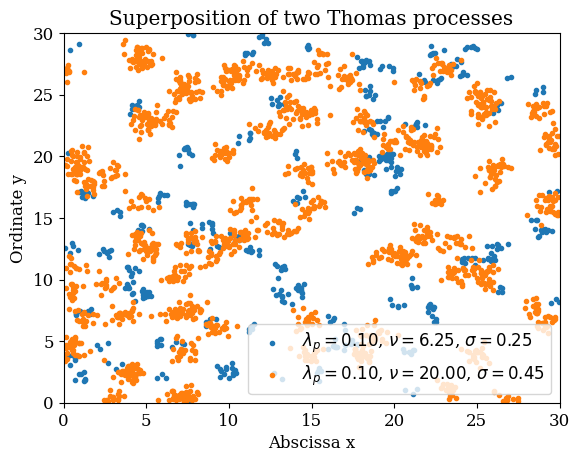

KeyboardInterrupt: 

In [59]:
D=estimate_parameters_from_spectrum(0.25, 20, 0.100, 100, W=params['W'])

**2 - Estimation over a grid of parameters and storage of the results**


In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools
from tqdm import tqdm

**Experiment**

In [61]:
sigma1_values = [0.1, 0.3, 0.5, 1.0]
ratios_sigma2 = [0.5, 1.0, 2.0]
lambda_p_values = [0.001, 0.01, 0.1]
mu = 100

results = []
I_values_dict = {}

# Boucle sur toutes les configurations
for sigma1, ratio, lam_p in tqdm(itertools.product(sigma1_values, ratios_sigma2, lambda_p_values), total=36):
    sigma2 = sigma1 * ratio
    nu2 = mu * sigma2 ** 2

    try:
        res = estimate_parameters_from_spectrum_2(sig1=sigma1, nu2=nu2, lam_p=lam_p, mu=mu, W=[60,60])
        
        key = (sigma1, sigma2, lam_p, mu)
        I_values_dict[key] = res["I_values"]
        
        # Extraction des estimations
        mu_hat, lam_p_hat, sig1_hat, sig2_hat, nu1_hat, nu2_hat = res["theta_est"]

        # Réels
        theta_true = [mu, lam_p, sigma1, sigma2, mu * sigma1**2, nu2]

        # Estimés
        theta_est = [mu_hat, lam_p_hat, sig1_hat, sig2_hat, mu_hat * sig1_hat**2, nu2_hat]

        rel_errors = 100 * np.abs((np.array(theta_est) - np.array(theta_true)) / np.array(theta_true))

        results.append({
            "mu_true": mu, "lambda_p_true": lam_p, "sigma1_true": sigma1, "sigma2_true": sigma2, "nu2_true": nu2,
            "mu_est": mu_hat, "lambda_p_est": lam_p_hat, "sigma1_est": sig1_hat, "sigma2_est": sig2_hat, "nu2_est": nu2_hat,
            "err_mu": rel_errors[0], "err_lambda_p": rel_errors[1], "err_sigma1": rel_errors[2],
            "err_sigma2": rel_errors[3], "err_nu1": rel_errors[4], "err_nu2": rel_errors[5],
            "rmse": res["rmse"]
        })

    except Exception as e:
        print(f"Erreur sur sigma1={sigma1}, ratio={ratio}, lambda_p={lam_p} : {e}")


df = pd.DataFrame(results)
df.to_csv("results_grid.csv", index=False)

# =========================
# results
# =========================
print("\n--- Moyennes des erreurs relatives (%) ---")
print(df[["err_mu", "err_lambda_p", "err_sigma1", "err_sigma2", "err_nu1", "err_nu2"]].mean())

# Meilleur, médian, pire cas selon RMSE
df_sorted = df.sort_values(by="rmse")
best_case = df_sorted.iloc[0]
median_case = df_sorted.iloc[len(df_sorted) // 2]
worst_case = df_sorted.iloc[-1]

print("\n--- Meilleur cas ---\n", best_case)
print("\n--- Cas médian ---\n", median_case)
print("\n--- Pire cas ---\n", worst_case)

# =========================
# Graphs
# =========================
plt.figure(figsize=(8, 4))
plt.hist(df["rmse"], bins=10, edgecolor='black')
plt.title("Distribution des RMSE")
plt.xlabel("RMSE")
plt.ylabel("Fréquence")
plt.grid(True)
plt.tight_layout()
plt.savefig("rmse_histogram.pdf")
plt.show()

plt.figure(figsize=(10, 5))
plt.boxplot([df["err_mu"], df["err_lambda_p"], df["err_sigma1"], df["err_nu2"]],
            labels=["mu", "lambda_p", "sigma1", "nu2"])
plt.title("Boxplot des erreurs relatives (%)")
plt.grid(True)
plt.ylabel("Erreur relative (%)")
plt.tight_layout()
plt.savefig("relative_error_boxplot.pdf")
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(df["mu_true"], df["mu_est"], label="mu", alpha=0.7)
plt.scatter(df["lambda_p_true"], df["lambda_p_est"], label="lambda_p", alpha=0.7)
plt.scatter(df["sigma1_true"], df["sigma1_est"], label="sigma1", alpha=0.7)
plt.scatter(df["nu2_true"], df["nu2_est"], label="nu2", alpha=0.7)
plt.plot([0, 1], [0, 1], transform=plt.gca().transAxes, color="gray", linestyle="--")
plt.xlabel("True value")
plt.ylabel("Estimated value")
plt.legend()
plt.title("Scatter plot: True vs Estimated")
plt.tight_layout()
plt.savefig("true_vs_estimated_scatter.pdf")
plt.show()

  3%|▎         | 1/36 [00:20<12:01, 20.62s/it]


Résultats d'estimation :

  Parameter  True value  Estimated value Relative error (%)
0        mu     100.000         0.332255              99.67
1  lambda_p       0.001         0.324741           32374.09
2      sig1       0.100         0.182589              82.59
3      sig2       0.050         0.005486              89.03
4       nu1       1.000         0.011077              98.89
5       nu2       0.250         0.000010             100.00


  3%|▎         | 1/36 [00:24<14:12, 24.37s/it]


KeyboardInterrupt: 

**Statistics of the experiment if you have to interrupt the code (when it is too long)**

In [62]:
import json
with open("results_checkpoint_2.json", "w") as f:
    json.dump(results, f, indent=2)


In [ ]:
Estimateur = I_values_dict 
# to save the values of the periodogram just in case 
# (because its is the computation of the periodogram that takes a really long time)


--- Moyennes des erreurs relatives (%) ---
err_mu            24.201248
err_lambda_p    4019.498556
err_sigma1        57.172212
err_sigma2        38.157821
err_nu1           64.670870
err_nu2           55.689411
dtype: float64

--- Meilleur cas ---
 mu_true          100.000000
lambda_p_true      0.010000
sigma1_true        0.300000
sigma2_true        0.300000
nu2_true           9.000000
mu_est            99.973573
lambda_p_est       0.019854
sigma1_est         0.017014
sigma2_est         0.286228
nu2_est            8.190481
err_mu             0.026427
err_lambda_p      98.540794
err_sigma1        94.328737
err_sigma2         4.590671
err_nu1           99.678453
err_nu2            8.994655
rmse               0.858020
Name: 12, dtype: float64

--- Cas médian ---
 mu_true          100.000000
lambda_p_true      0.100000
sigma1_true        0.500000
sigma2_true        0.250000
nu2_true           6.250000
mu_est           104.914186
lambda_p_est       0.087776
sigma1_est         0.519147
sigm

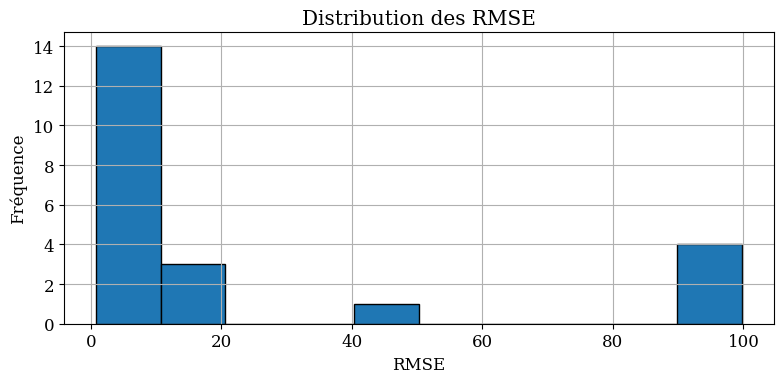

/var/folders/td/3pvgc2y93xj64n2l7qv2_gkw0000gn/T/ipykernel_32912/1550711429.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df["err_mu"], df["err_lambda_p"], df["err_sigma1"], df["err_nu2"]],


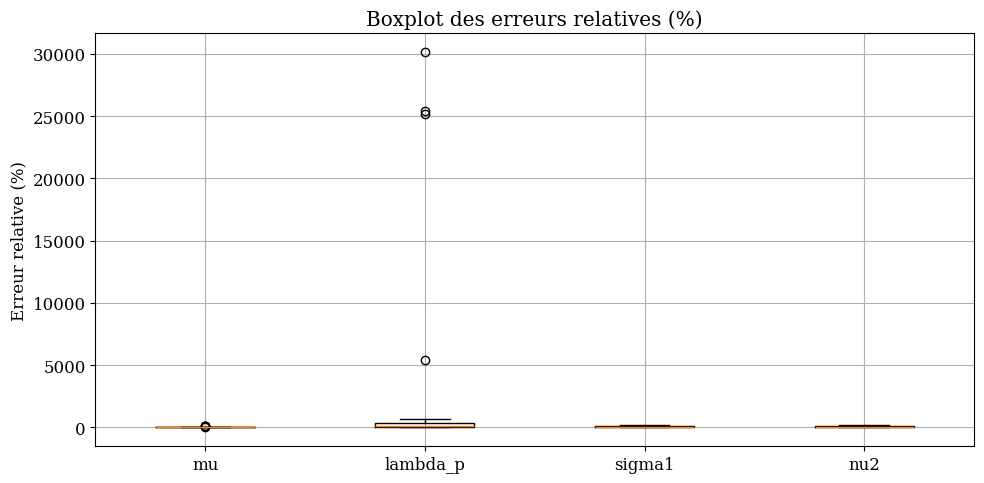

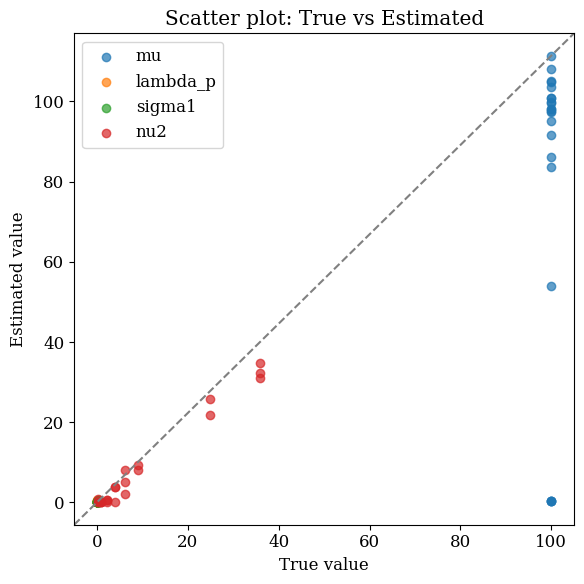

In [49]:
df = pd.DataFrame(results)
df.to_csv("results_grid.csv", index=False)

# =========================
# results
# =========================
print("\n--- Moyennes des erreurs relatives (%) ---")
print(df[["err_mu", "err_lambda_p", "err_sigma1", "err_sigma2", "err_nu1", "err_nu2"]].mean())

# Meilleur, médian, pire cas selon RMSE
df_sorted = df.sort_values(by="rmse")
best_case = df_sorted.iloc[0]
median_case = df_sorted.iloc[len(df_sorted) // 2]
worst_case = df_sorted.iloc[-1]

print("\n--- Meilleur cas ---\n", best_case)
print("\n--- Cas médian ---\n", median_case)
print("\n--- Pire cas ---\n", worst_case)

# =========================
# Graphs
# =========================
plt.figure(figsize=(8, 4))
plt.hist(df["rmse"], bins=10, edgecolor='black')
plt.title("Distribution des RMSE")
plt.xlabel("RMSE")
plt.ylabel("Fréquence")
plt.grid(True)
plt.tight_layout()
plt.savefig("rmse_histogram.pdf")
plt.show()

plt.figure(figsize=(10, 5))
plt.boxplot([df["err_mu"], df["err_lambda_p"], df["err_sigma1"], df["err_nu2"]],
            labels=["mu", "lambda_p", "sigma1", "nu2"])
plt.title("Boxplot des erreurs relatives (%)")
plt.grid(True)
plt.ylabel("Erreur relative (%)")
plt.tight_layout()
plt.savefig("relative_error_boxplot.pdf")
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(df["mu_true"], df["mu_est"], label="mu", alpha=0.7)
plt.scatter(df["lambda_p_true"], df["lambda_p_est"], label="lambda_p", alpha=0.7)
plt.scatter(df["sigma1_true"], df["sigma1_est"], label="sigma1", alpha=0.7)
plt.scatter(df["nu2_true"], df["nu2_est"], label="nu2", alpha=0.7)
plt.plot([0, 1], [0, 1], transform=plt.gca().transAxes, color="gray", linestyle="--")
plt.xlabel("True value")
plt.ylabel("Estimated value")
plt.legend()
plt.title("Scatter plot: True vs Estimated")
plt.tight_layout()
plt.savefig("true_vs_estimated_scatter.pdf")
plt.show()

**An Experiment without Lambda_p = 0.001 and with W=[20,20] and with less points for the computation of I_values (400 instead of 1000)**

In [63]:
def estimate_parameters_from_spectrum_3(sig1, nu2, lam_p, mu, W=params['W']):
    
    seed1 = random.randint(0, 10**6)
    seed2 = random.randint(0, 10**6)
    
    w, h = W
    nu1, sig2 = mu*sig1**2, np.sqrt(nu2/mu)
    theta_real = [mu, lam_p, sig1, nu2]


    # Génération des deux Thomas process
    thomas_process1 = ThomasProcess(lam_p, nu1, sig1)
    parents1, points_thomas1 = thomas_process1.generate(W, seed=seed1)
    thomas_process2 = ThomasProcess(lam_p, nu2, sig2)
    parents2, points_thomas2 = thomas_process2.generate(W, seed=seed2)
    points_sup = np.concatenate([points_thomas1, points_thomas2])

    # # Affichage de la superposition
    # display_superposition([points_thomas1, points_thomas2],
    #                        window=W,
    #                        title="Superposition of two Thomas processes",
    #                        labels=[
    #                            fr"$\lambda_p = {lam_p:.2f}$, $\nu = {nu1:.2f}$, $\sigma = {sig1:.2f}$",
    #                            fr"$\lambda_p = {lam_p:.2f}$, $\nu = {nu2:.2f}$, $\sigma = {sig2:.2f}$"
    #                        ])

    # Périodogramme par tapering triangulaire
    threshold = 0.2
    r_values = np.linspace(threshold, w/4, 400) #you can adjust the number of points (400 here) 
    I_values = periodogram_tapering(points_sup, W, r_values, taper_triangle)

    # Estimation de l’intensité totale
    lam_hat = intensity(points_sup, W)

    # def des fonctions qui vont être utiles
    def f_theo_sup_2(theta, r):
        mu, lam_p, sig1, nu2 = theta
        return lam_p*(mu*sig1**2 + nu2) + (lam_hat/(mu*sig1**2 + nu2))*(mu**2*sig1**4*np.exp(-4*np.pi**2*sig1**2*r**2) + nu2**2*np.exp(-4*np.pi**2*nu2*r**2/mu))
    
    def contrast_aux_2(theta):
        g_theo = f_theo_sup_2(theta, r_values)
        dr = r_values[1] - r_values[0]
        return contrast(I_values, g_theo, dr)
    
    def rmse(y_true, y_pred):
        return np.sqrt(np.sum((y_true - y_pred)**2))
    
    def mape(y_true, y_pred):
        y_true = np.array(y_true)
        y_pred = np.array(y_pred)
        return np.abs((y_true - y_pred) / y_true) * 100


    # Choix des points initiaux pour l'algo d'optimisation
    mu_values = np.linspace(1, 200, 5)
    lamp_values = np.linspace(0.0005, 0.2, 5)
    sig1_values = np.linspace(0.05, 1.5, 5)
    nu2_values = np.linspace(0.05, 450, 5)

    param_grid = ParameterGrid({'mu': mu_values, 'lam_p': lamp_values, 'sig1': sig1_values, 'nu2': nu2_values})
    rmse_min, result_min, theta0_min = float('inf'), None, None

    for params in param_grid:
        theta0 = list(params.values())  # points initiaux
        bounds = [(1e-5, None)]*4 # intervalle de recherche 

        result = minimize(contrast_aux_2, theta0, method='L-BFGS-B', bounds=bounds)
        rmse_ = rmse(theta_real, result.x)
        if rmse_ < rmse_min:
            rmse_min, result_min, theta0_min = rmse_, result.x, theta0
    
    mu_hat, lamp_hat, sig1_hat, nu2_hat = result_min
    nu1_hat, sig2_hat = mu_hat*sig1_hat**2, np.sqrt(nu2_hat/mu_hat)
    theta_est = [mu_hat, lamp_hat, sig1_hat, nu2_hat]
    
    
    # # Affichage : comparaison spectre réel vs estimateur
    # plt.plot(r_values, f_theo_sup_2(theta_real, r_values), label='theoretical (true)', color='green')
    # plt.plot(r_values, I_values, linestyle='-', color='orange', label='periodogram')
    # plt.legend()
    # plt.title("True vs Periodogram")
    # plt.show()

    # # Affichage : comparaison spectre avec estimation vs estimateur
    # plt.plot(r_values, f_theo_sup_2(theta_est, r_values), label='theoretical (estimated)', color='blue')
    # plt.plot(r_values, I_values, linestyle='-', color='orange', label='periodogram')
    # plt.legend()
    # plt.title("Estimated vs Periodogram")
    # plt.show()

    # Résultats
    
    param_names = ["mu", "lambda_p", "sig1", "sig2", "nu1", "nu2"]
    real_vals = [mu, lam_p, sig1, sig2, nu1, nu2]
    est_vals = [mu_hat, lamp_hat, sig1_hat, sig2_hat, nu1_hat, nu2_hat]
    rel_errors = [100 * abs(est - real) / real for est, real in zip(est_vals, real_vals)]

    df_results = pd.DataFrame({
        "Parameter": param_names,
        "True value": real_vals,
        "Estimated value": est_vals,
        "Relative error (%)": [f"{e:.2f}" for e in rel_errors]
        })

    print("\nRésultats d'estimation :\n")
    print(df_results)
    
    #print(df_results.to_markdown(index=False))
    
    return {
        "theta_true": real_vals,
        "theta_est": list(est_vals),
        "theta0_used": theta0_min,
        "relative_errors": mape(theta_est, theta_real),
        "rmse": rmse_min,
        "I_values": I_values
    }


In [64]:
sigma1_values = [0.1, 0.3, 0.5, 1.0]
ratios_sigma2 = [0.5, 1.0, 2.0]
lambda_p_values = [ 0.01, 0.1]
mu = 100

results = []
I_values_dict = {}

# Boucle sur toutes les configurations
for sigma1, ratio, lam_p in tqdm(itertools.product(sigma1_values, ratios_sigma2, lambda_p_values), total=24):
    sigma2 = sigma1 * ratio
    nu2 = mu * sigma2 ** 2

    try:
        res = estimate_parameters_from_spectrum_3(sig1=sigma1, nu2=nu2, lam_p=lam_p, mu=mu, W=[20,20])
        
        key = (sigma1, sigma2, lam_p, mu)
        I_values_dict[key] = res["I_values"]
        
        # Extraction des estimations
        mu_hat, lam_p_hat, sig1_hat, sig2_hat, nu1_hat, nu2_hat = res["theta_est"]

        # Réels
        theta_true = [mu, lam_p, sigma1, sigma2, mu * sigma1**2, nu2]

        # Estimés
        theta_est = [mu_hat, lam_p_hat, sig1_hat, sig2_hat, mu_hat * sig1_hat**2, nu2_hat]

        rel_errors = 100 * np.abs((np.array(theta_est) - np.array(theta_true)) / np.array(theta_true))

        results.append({
            "mu_true": mu, "lambda_p_true": lam_p, "sigma1_true": sigma1, "sigma2_true": sigma2, "nu2_true": nu2,
            "mu_est": mu_hat, "lambda_p_est": lam_p_hat, "sigma1_est": sig1_hat, "sigma2_est": sig2_hat, "nu2_est": nu2_hat,
            "err_mu": rel_errors[0], "err_lambda_p": rel_errors[1], "err_sigma1": rel_errors[2],
            "err_sigma2": rel_errors[3], "err_nu1": rel_errors[4], "err_nu2": rel_errors[5],
            "rmse": res["rmse"]
        })

    except Exception as e:
        print(f"Erreur sur sigma1={sigma1}, ratio={ratio}, lambda_p={lam_p} : {e}")


df = pd.DataFrame(results)
df.to_csv("results_grid.csv", index=False)

# =========================
# results
# =========================
print("\n--- Moyennes des erreurs relatives (%) ---")
print(df[["err_mu", "err_lambda_p", "err_sigma1", "err_sigma2", "err_nu1", "err_nu2"]].mean())

# Meilleur, médian, pire cas selon RMSE
df_sorted = df.sort_values(by="rmse")
best_case = df_sorted.iloc[0]
median_case = df_sorted.iloc[len(df_sorted) // 2]
worst_case = df_sorted.iloc[-1]

print("\n--- Meilleur cas ---\n", best_case)
print("\n--- Cas médian ---\n", median_case)
print("\n--- Pire cas ---\n", worst_case)

# =========================
# Graphs
# =========================
plt.figure(figsize=(8, 4))
plt.hist(df["rmse"], bins=10, edgecolor='black')
plt.title("Distribution des RMSE")
plt.xlabel("RMSE")
plt.ylabel("Fréquence")
plt.grid(True)
plt.tight_layout()
plt.savefig("rmse_histogram.pdf")
plt.show()

plt.figure(figsize=(10, 5))
plt.boxplot([df["err_mu"], df["err_lambda_p"], df["err_sigma1"], df["err_nu2"]],
            labels=["mu", "lambda_p", "sigma1", "nu2"])
plt.title("Boxplot des erreurs relatives (%)")
plt.grid(True)
plt.ylabel("Erreur relative (%)")
plt.tight_layout()
plt.savefig("relative_error_boxplot.pdf")
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(df["mu_true"], df["mu_est"], label="mu", alpha=0.7)
plt.scatter(df["lambda_p_true"], df["lambda_p_est"], label="lambda_p", alpha=0.7)
plt.scatter(df["sigma1_true"], df["sigma1_est"], label="sigma1", alpha=0.7)
plt.scatter(df["nu2_true"], df["nu2_est"], label="nu2", alpha=0.7)
plt.plot([0, 1], [0, 1], transform=plt.gca().transAxes, color="gray", linestyle="--")
plt.xlabel("True value")
plt.ylabel("Estimated value")
plt.legend()
plt.title("Scatter plot: True vs Estimated")
plt.tight_layout()
plt.savefig("true_vs_estimated_scatter.pdf")
plt.show()

  4%|▍         | 1/24 [00:16<06:21, 16.60s/it]


Résultats d'estimation :

  Parameter  True value  Estimated value Relative error (%)
0        mu      100.00         0.315878              99.68
1  lambda_p        0.01         0.470853            4608.53
2      sig1        0.10         0.264738             164.74
3      sig2        0.05         0.005627              88.75
4       nu1        1.00         0.022139              97.79
5       nu2        0.25         0.000010             100.00


  4%|▍         | 1/24 [00:18<07:11, 18.77s/it]


KeyboardInterrupt: 